### Consider only petal length and sepal length
### Consider only versicolor and viginica
   1. Classification by Linear Regression Algorithm and plot results
   2. Classification by Logistic Regression Algorithm and plot results
   3. Compare results from three classification algorithms (perceptron, linear, logistic)

In [15]:
# Importing libraries
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
import scipy.stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import preprocessing
from collections import Counter
from matplotlib.colors import ListedColormap
plt.style.use('ggplot')

%matplotlib inline

# Perceptron

In [26]:
class Perceptron(object):
    # Initiating the learning rate and number of iterations
    def __init__(self, learning_rate = 0.1, iterations = 50):
        self.learning_rate = learning_rate
        self.iterations = iterations
        
    def fit(self, X, y):
        self.w_ = np.zeros(X.shape[1])
        self.errors_ = []

        for _ in range(self.iterations):
            error = 0
            for xi, target in zip(X, y):
                update      = self.learning_rate * (target - self.predict(xi))
                self.w_[:] += update*xi
                error      += int(update != 0.0)
            self.errors_.append(error)
        return self

    def predict(self, x):
        return np.where(np.dot(x, self.w_[:]) >= 0.0, 1, -1)

In [27]:
def main(choice):
    dataFile = './iris.txt'

    X, y = formatIris(dataFile)   # X includes 1 for the bias: X = [[1,x11, x12], [1,x21,x22], .... [1,xN1, xN2]]T
    
    # print(X)
    # print(y)

    eta = 0.1   # learning rate

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    X_std = np.copy(X)
    X_std[:,1] = (X[:,1] - X[:,1].mean()) / X[:,1].std()   # sepal len
    X_std[:,2] = (X[:,2] - X[:,2].mean()) / X[:,2].std()   # petal len
    
    
    if choice == 1:
        # Perceptron
        ppn = Perceptron(eta)   #, iter=len(y))
        ppn.fit(X, y)

        plot_regions(choice, X, y, classifier = ppn)
        
    elif choice == 2:
        # Linear Regression
        Lin_reg = LinearRegression()
        
        # fit our LR to our data
        Lin_reg.fit(X, y)
        plot_regions(choice, X, y, classifier = Lin_reg)
        
    elif choice == 3:
        # Logistic Regression
        Log_reg = LogisticRegression()
        
        # fit our LR to our data
        Log_reg.fit(X, y)
        plot_regions(choice, X, y, classifier = Log_reg)

In [28]:
# get sepal and petal lengths of iris-vericolor and iris-virginica
def formatIris(dataset):
    X = []
    y = []
    with open(dataset, 'r') as f:
        for line in f:
            sline = line.replace('\n','')
            t = sline.split(',')
            if   t[4]=='Iris-versicolor': val = 1
            elif t[4]=='Iris-virginica':  val = -1
            else: val = 0

            X.append([1, float(t[0]), float(t[2])])   # [1, sepal len, petal len]
            y.append(val)
    return np.array(X), np.array(y)

In [29]:
def plot_regions(choice, X, y, classifier, resolution = 0.02):
    # setup marker generator and color map
    plt.figure(figsize = (10,10))
    markers = ('o', 'x', 's', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:,1].min() - 1, X[:,1].max()+1
    x2_min, x2_max = X[:,2].min() - 1, X[:,2].max()+1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution), np.arange(x2_min, x2_max, resolution))
   
    coordinates = np.array([np.ones(len(xx1.ravel())), xx1.ravel(), xx2.ravel()])
    region = np.dot(coordinates.T, classifier.w_[:])
    Z = np.where(region >= 0.0, 1, -1)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.4, cmap=cmap)
   
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x = X[y==cl, 1], y = X[y==cl, 2], alpha=0.8, color=cmap(idx), marker=markers[idx], label=cl)

    if choice == 1:
        plt.title("Perceptron")
    elif choice == 2:
        plt.title("Linear Regression")
    elif choice == 3:
        plt.title("Logistic Regression")
    plt.xlabel('sepal length')
    plt.ylabel('petal length')
    plt.legend(loc = 'upper right')
    plt.show()

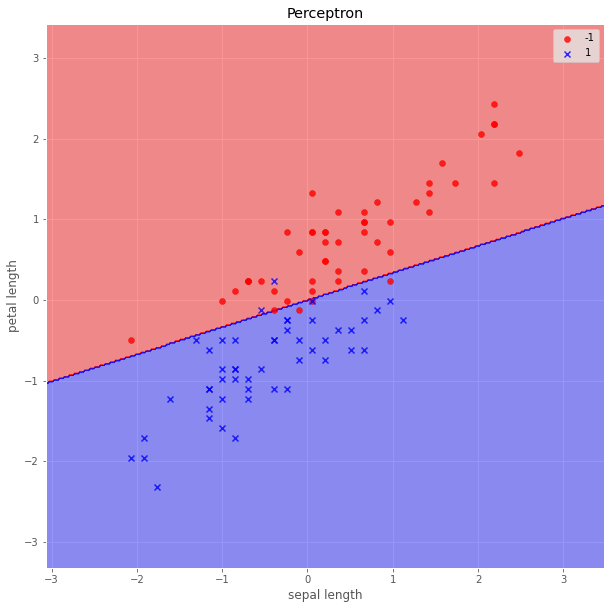

In [30]:
main(1)

# Linear Regression Algorithm

In [39]:
class LinearRegression():
    def __init__(self, learning_rate = 0.1, iterations = 50):
        self.learning_rate = learning_rate
        self.iterations = iterations

    # Function for model training
    def fit(self, X, y):
        self.m, self.n = X.shape

        # weight initialization
        self.w_ = np.zeros(X.shape[1])
        
        self.b = 0
        self.X = X
        self.y = y

        # gradient descent learning
        for i in range(self.iterations):
            self.update_weights()
        return self

    # Helper function to update weights in gradient descent
    def update_weights(self):
        Y_pred = self.predict(self.X)

        # calculate gradients
        dW = -(2*(self.X.T).dot(self.y - Y_pred)) / self.m
        db = -2*np.sum(self.y - Y_pred) / self.m

        # update weights
        self.w_ = self.w_ - self.learning_rate * dW
        self.b = self.b - self.learning_rate * db
        return self

    # Hypothetical function h(x)
    def predict(self, X):
        return np.where(np.dot(X, self.w_[:]) >= 0.0, 1, -1)

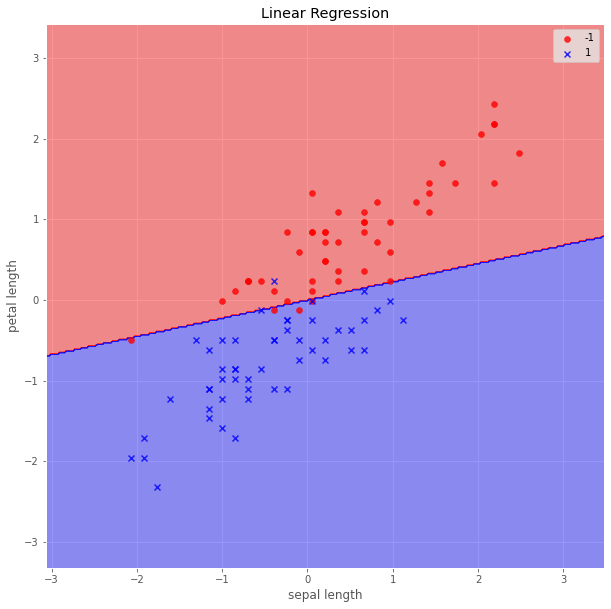

In [40]:
main(2)

# Logistic Regression Algorithm

In [47]:
class LogisticRegression():
    def __init__(self, learning_rate = 0.1, iterations = 50):
        self.learning_rate = learning_rate
        self.iterations = iterations

    # Function for model training
    def fit(self, X, y):
        self.m, self.n = X.shape

        # weight initialization
        self.w_ = np.zeros(X.shape[1])
        self.b = 0
        self.X = X
        self.y = y

        # gradient descent learning
        for i in range(self.iterations):
            self.update_weights()
        return self

    # Helper function to update weights in gradient descent
    def update_weights(self):
        A = 1/(1 + np.exp(-(self.X.dot(self.w_) + self.b)))

        # calculate gradients
        tmp = (A - self.y.T)
        tmp = np.reshape(tmp, self.m)
        dW = np.dot(self.X.T, tmp) / self.m
        db = np.sum(tmp) / self.m

        # update weights
        self.w_ = self.w_ - self.learning_rate * dW
        self.b = self.b - self.learning_rate * db
        
        return self

    # Hypothetical function h(x)
    def predict(self, X):
        Z = 1 / (1 + np.exp(-(X.dot(self.w_) + self.b)))
        y = np.where(Z >= 0.0, 1, -1)
        
        return Y

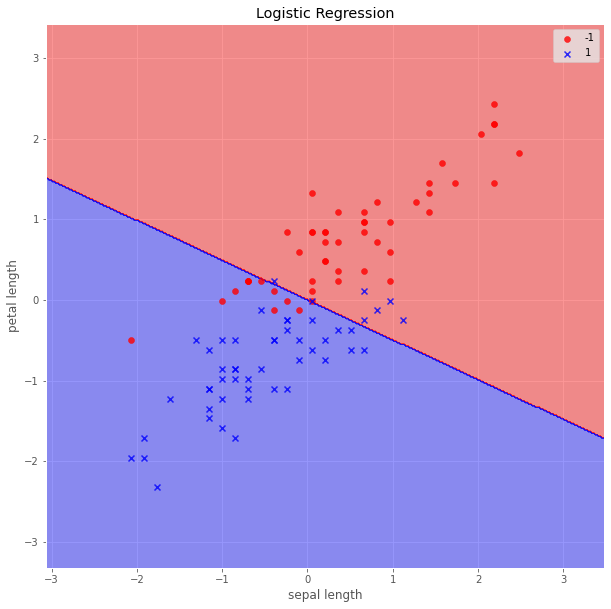

In [48]:
main(3)